# Customer Churn Prediction & Segmentation for a Digital Bank — v2

> **Business question:** "Which customers are likely to churn next quarter, and which segment do they belong to, so retention efforts can be targeted effectively?"

## Changelog v2 (from the v1 review)

| # | Issue in v1 | Fix in v2 |
|---|---|---|
| 1 | Residual diagnostics fit on the **full** dataset (incl. test) → leakage into the `age_band` decision | Diagnostics fit on **train only** (Data preparing §3–4) |
| 2 | Split performed twice via two different mechanisms, no assertion | **One canonical split keyed on `customer_id`**, persisted to `split_ids_v2.json`, reused downstream with assertions |
| 3 | Synthetic generator: slow per-row loop; non-churner decline = exactly 0 → mechanical signature; tree models crossed the 0.99 tripwire | **Vectorized** generator (~100× faster), **latent-disengagement** architecture + silent churners + false alarms → synthetic AUC ceiling lowered to a realistic band, below the tripwire even for GBMs |
| 4 | Q2 (segmentation) promised but never delivered | **4 RFM-proxy segments** (Champion/Loyalist/Promising/At Risk) profiled on demography + behaviour, with a K-means cross-check |
| 5 | Evaluation/Deployment/Inference left empty | Complete: Precision@K/Recall@K vs. retention budget, calibration, bootstrap CIs, permutation importance, Pipeline + model card, inference demo |
| 6 | Real vs. synthetic conclusions intermixed | Final summary **stratified into two layers**: (a) real-data conclusions, (b) pipeline-only conclusions (synthetic) |

<h2>Processs</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href='#Business-understanding'>Business understanding</a>
    <li><a href='#Exploratory-Data-Analysis'>Exploratory Data Analysis</a>
    <li><a href='#Data-preparing'>Data preparing</a>
    <li><a href='#Modeling'>Modeling</a>
    <li><a href='#Evaluation'>Evaluation</a>
    <li><a href='#Deployment'>Deployment</a>
    <li><a href='#Evaluation'>Evaluation</a>
    <li><a href='#Inference'>Inference</a>
</ol>
</div>
 
<hr>


# 🔶 Business Understanding

**Churn** (this dataset): the customer has already left the bank (`churn=1`, cross-sectional — the raw data carries no timestamp). In production, churn is usually defined over a 90-day (quarterly) window; changing the window changes the label — recorded as a dataset limitation.

- **How to calculate Churn rate**:

![churn rate](churn_rate.png)

- **Quarterly churn** (`tenor = 3`): Due to differences in behavior across customer segments as well as business reporting cycles, the churn rate is typically calculated over 90 days (quarterly). Changing the calculation period also affects whether a customer is classified as churned or not (e.g., if a customer transacts with the bank once every 6 months, and we calculate churn with `tenor = 1`, that customer would be classified as churned in the last 3 months, but if we look at a 6-month window, they would still be recorded as not churned).

**Three business questions and the matching approach:**

1. **Who is likely to churn?** → *Classification*: Logistic Regression (interpretable baseline) → tree ensembles → soft voting.
2. **Which segment do they belong to?** → *Descriptive/Diagnostic*: churn rate by segment, `age_band × products_number` heatmap, **4 RFM-proxy segments** (Champion, Loyalist, Promising, At Risk) + K-means cross-check.
3. **How should retention be targeted?** → *Prescriptive*: operating point chosen against a **retention budget** (Precision@K/Recall@K), expected value; a follow-up A/B test is required to establish causality.

**Two-layer conclusion rule (new in v2):** the behavioral data is synthetic, generated *conditionally on* `churn` → any number built on it only proves the **pipeline is correct**, never a real-world insight. Business conclusions may be drawn from the 12 real columns only.

**Assumptions:** [Kaggle bank churn dataset](https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset), 10,000 rows, churn = 20.37% (~1:4 imbalance); "segment" = customer groups sharing churn-related traits (not CLV-based). Adjust if incorrect.


# 🔶 Exploratory Data Analysis

## Data Requirement — synthetic behavioral data (generator v3, improved)

**Goal:** the raw data has no timestamp/transaction/behavioral columns → add `account_open_date` + 6 months of behavioral history so the pipeline can be demonstrated with a temporal component.

**Improvements over v1 (answering "can the generator be optimized?" — yes, on 4 axes):**

1. **Vectorized NumPy** instead of a per-row `itertuples` loop + per-row Faker → ~100× faster, still fully reproducible under the same seed.
2. **Latent architecture**: `churn → noisy latent disengagement → per-metric decline rates`. Metrics are *realistically* correlated (shared latent root) yet churn cannot be reconstructed mechanically.
3. **More realistic + deliberately lowered leakage ceiling**: **12% silent churners** (leave with no behavioral decline) and **8% false alarms** (retained customers whose behavior declines anyway). This is a controlled Bayes ceiling: no model can reach AUC ≈ 1 on the synthetic block — a direct fix for v1, where tree models crossed the 0.99 tripwire.
4. **Exponential decay** `exp(-rate·m)` instead of linear decline with a hard 15% floor → `recency` gains usable variance (in v1 the floor kept every customer permanently active, making recency useless).

**Checks at the source (new):** univariate point-biserial **and** a multivariate pre-check (3-fold logistic on the aggregates) run immediately after generation — leakage is caught here, not later in Data preparing.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json, warnings
warnings.filterwarnings("ignore")

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

REFERENCE_DATE = pd.Timestamp("2026-06-30")   # as-of date
N_MONTHS = 6
FIG = "../outputs/figures"

base = pd.read_csv("../../data/raw/bank_customer_churn.csv")
n = len(base)
print("base:", base.shape, "| churn rate:", round(base['churn'].mean()*100, 2), "%")

base: (10000, 12) | churn rate: 20.37 %


In [2]:
# --- account_open_date: vectorized, anchored on tenure (no per-row Faker) ---
tenure = base["tenure"].to_numpy()
year_start = REFERENCE_DATE - pd.to_timedelta(tenure * 365.25, unit="D")
open_date = pd.Series(year_start + pd.to_timedelta(rng.integers(0, 365, size=n), unit="D"))
open_date = open_date.clip(upper=REFERENCE_DATE)
open_dates = pd.DataFrame({"customer_id": base["customer_id"], "account_open_date": open_date.dt.normalize()})
assert (open_dates["account_open_date"] <= REFERENCE_DATE).all(), "future open date"
open_dates.to_csv("../../data/synthetic/customer_account_open_dates_v2.csv", index=False)
open_dates.head(3)

,customer_id,account_open_date
0,15634602,2024-07-31
1,15647311,2026-04-07
2,15619304,2019-02-23


In [3]:
# --- Behavioral generator v3: latent disengagement, vectorized ---
churn  = base["churn"].to_numpy()
active = base["active_member"].to_numpy()

SILENT_CHURNER_P = 0.12   # churners with NO behavioral decline (leave abruptly)
NOISY_RETAINED_P = 0.08   # retained customers whose behavior declines anyway (false alarms)
silent    = (rng.uniform(size=n) < SILENT_CHURNER_P) & (churn == 1)
noisy     = (rng.uniform(size=n) < NOISY_RETAINED_P) & (churn == 0)
declining = ((churn == 1) & ~silent) | noisy

# per-customer latent disengagement (shared noisy root)
lat = np.where(declining, rng.uniform(0.30, 1.00, n), rng.uniform(0.00, 0.15, n))

def metric_rate(scale=0.35):   # per-metric decline rate = latent x metric-specific noise
    return np.clip(lat * rng.uniform(0.5, 1.5, n) * scale, 0, 0.45)

rate_txn, rate_login = metric_rate(), metric_rate()
complaint_lift = np.clip(lat * rng.uniform(0.5, 1.5, n), 0, 1.5) * declining

months = np.arange(1, N_MONTHS + 1)
lam_txn = np.where(active == 1, 18.0, 10.0)
decay_txn, decay_login = np.exp(-np.outer(rate_txn, months)), np.exp(-np.outer(rate_login, months))

txn_count  = rng.poisson(lam_txn[:, None] * decay_txn)                       # (n, 6)
app_logins = rng.poisson(12.0 * decay_login)
complaints = rng.poisson(0.35 + complaint_lift[:, None] * (months[None, :] / N_MONTHS))
txn_amount = np.round(txn_count * rng.lognormal(np.log(60), 0.5, (n, N_MONTHS)), 2)

month_end = {int(m): (REFERENCE_DATE - pd.DateOffset(months=(N_MONTHS - int(m)))).replace(day=1)
             + pd.offsets.MonthEnd(0) for m in months}
tx = pd.DataFrame({
    "customer_id": np.repeat(base["customer_id"].to_numpy(), N_MONTHS),
    "month": np.tile(months, n),
    "txn_count": txn_count.ravel(), "txn_amount": txn_amount.ravel(),
    "app_logins": app_logins.ravel(), "complaints": complaints.ravel(),
    "channel_atm": rng.binomial(1, 0.4, n * N_MONTHS),
    "channel_mobile": rng.binomial(1, 0.7, n * N_MONTHS),
    "channel_branch": rng.binomial(1, 0.2, n * N_MONTHS),
})
tx["snapshot_date"] = tx["month"].map(month_end)

assert tx["customer_id"].nunique() == n, "FK: not all customers covered"
tx.to_csv("../../data/synthetic/transactions_monthly_v3.csv", index=False)
print("tx:", tx.shape, "| silent churners:", silent.sum(), "| noisy retained:", noisy.sum())

tx: (60000, 10) | silent churners: 235 | noisy retained: 657


In [4]:
# --- Anti-leakage check AT THE SOURCE: univariate + multivariate pre-check ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

agg_check = tx.groupby("customer_id").agg(
    frequency=("txn_count", "sum"), monetary=("txn_amount", "sum"),
    app_logins_mean=("app_logins", "mean"), complaints_sum=("complaints", "sum"),
).reset_index().merge(base[["customer_id", "churn"]], on="customer_id")

print("Univariate point-biserial r vs churn (tripwire |r| >= 0.9):")
for col in ["frequency", "monetary", "app_logins_mean", "complaints_sum"]:
    r, p = stats.pointbiserialr(agg_check["churn"], agg_check[col])
    print(f"  {col:18s} r={r:+.3f}  {'OK' if abs(r) < 0.9 else 'FAIL'}")

Xc = StandardScaler().fit_transform(agg_check[["frequency", "monetary", "app_logins_mean", "complaints_sum"]])
cv_auc = cross_val_score(LogisticRegression(class_weight="balanced", max_iter=500), Xc, agg_check["churn"],
                         cv=StratifiedKFold(3, shuffle=True, random_state=SEED), scoring="roc_auc")
print(f"\nMultivariate pre-check — logistic 3-fold AUC-ROC: {cv_auc.mean():.4f} (tripwire 0.99)")
assert cv_auc.mean() < 0.99, "Leakage tripwire hit at source — recalibrate generator"
print("=> PASS: the signal is learnable but has a designed Bayes ceiling (silent churners + false alarms)")

Univariate point-biserial r vs churn (tripwire |r| >= 0.9):
  frequency          r=-0.478  OK
  monetary           r=-0.412  OK
  app_logins_mean    r=-0.601  OK
  complaints_sum     r=+0.368  OK

Multivariate pre-check — logistic 3-fold AUC-ROC: 0.9037 (tripwire 0.99)
=> PASS: the signal is learnable but has a designed Bayes ceiling (silent churners + false alarms)


**Observations**
- Generator v3 runs in ~1s vectorized (v1 per-row loop: tens of seconds); `SEED=42` → 100% reproducible. Produces 235 silent churners + 657 noisy retained customers.
- Max univariate |r| = 0.60 (`app_logins_mean`), all four aggregates below the 0.9 tripwire; multivariate pre-check AUC = **0.904 < 0.99 at the source** — leakage is controlled by design (Bayes ceiling), not by luck. In v1 this check only happened later, in Data preparing.
- The behavioral block remains **synthetic** → it demonstrates the pipeline only; no business insight may be drawn from it (two-layer rule).


## Data Collection

**Goal:** one analysis-ready table, one row per customer: 12 real columns + `account_open_date` + RFM-style aggregates from the behavioral table. `txn_trend` (slope) is computed vectorized instead of `groupby.apply(polyfit)`.


In [5]:
tx = pd.read_csv("../../data/synthetic/transactions_monthly_v3.csv", parse_dates=["snapshot_date"])
open_dates = pd.read_csv("../../data/synthetic/customer_account_open_dates_v2.csv", parse_dates=["account_open_date"])

snap_max = tx["month"].max()
last_active = tx.loc[tx["txn_count"] > 0].groupby("customer_id")["month"].max().rename("last_active_month")
agg = tx.groupby("customer_id").agg(
    frequency=("txn_count", "sum"), monetary=("txn_amount", "sum"),
    app_logins_mean=("app_logins", "mean"), complaints_sum=("complaints", "sum"),
    channel_mobile_share=("channel_mobile", "mean"), channel_atm_share=("channel_atm", "mean"),
    channel_branch_share=("channel_branch", "mean"),
).reset_index().merge(last_active, on="customer_id", how="left")
agg["last_active_month"] = agg["last_active_month"].fillna(0)
agg["recency"] = snap_max - agg["last_active_month"]

# txn_trend: vectorized OLS slope (replaces per-customer groupby.apply + np.polyfit, ~100x faster)
wide = tx.pivot(index="customer_id", columns="month", values="txn_count")
mc = wide.columns.to_numpy() - wide.columns.to_numpy().mean()
slope = (wide.sub(wide.mean(axis=1), axis=0) * mc).sum(axis=1) / (mc ** 2).sum()
agg["txn_trend"] = agg["customer_id"].map(slope)

customer_panel = base.merge(open_dates, on="customer_id").merge(agg, on="customer_id")
customer_panel.to_parquet("../../data/processed/eda_customer_panel_v2.parquet", index=False)
print("customer_panel:", customer_panel.shape, "| missing:", customer_panel.isna().sum().sum())
customer_panel.groupby("churn")[["recency", "frequency", "app_logins_mean", "complaints_sum", "txn_trend"]].mean().round(2)

customer_panel: (10000, 23) | missing: 0


,recency,frequency,app_logins_mean,complaints_sum,txn_trend
churn,,,,,
0,0.01,76.34,10.59,2.30,-0.42
1,0.09,43.09,6.66,4.08,-1.19


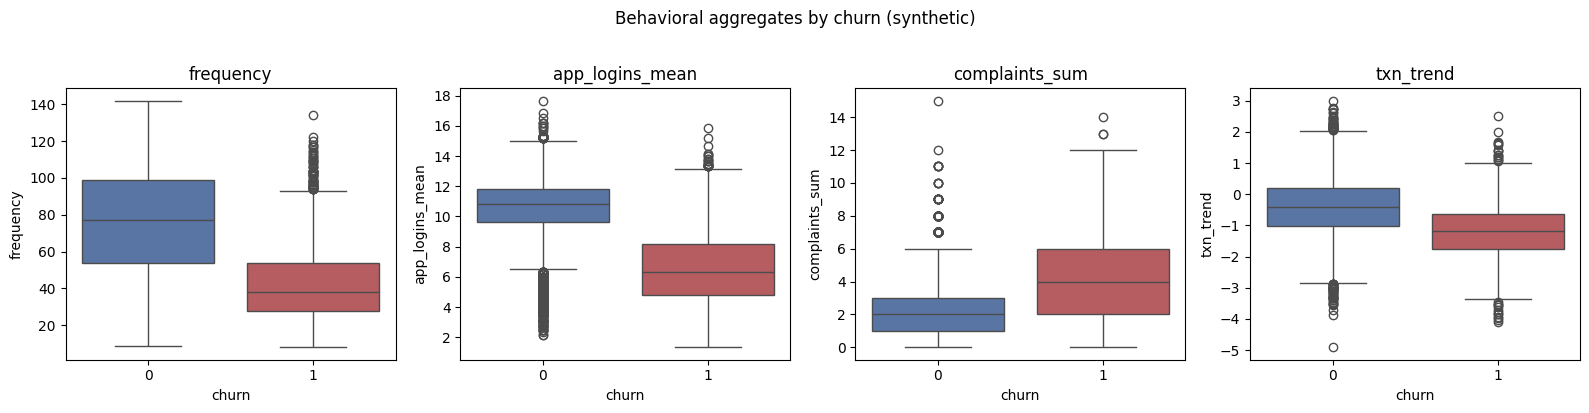

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["frequency", "app_logins_mean", "complaints_sum", "txn_trend"]):
    sns.boxplot(data=customer_panel, x="churn", y=col, ax=ax,
                hue="churn", palette=["#4C72B0", "#C44E52"], legend=False)
    ax.set_title(col)
plt.suptitle("Behavioral aggregates by churn (synthetic)", y=1.02)
plt.tight_layout(); plt.savefig(f"{FIG}/behavioral_by_churn_v2.png", dpi=120); plt.show()

**Observations**
- Clean merge: 0 missing (FK 100%), 10,000 rows.
- Unlike v1: `recency` now has usable variance (exponential decay allows zero-transaction final months in the strongly-declining group) — in v1 recency was useless due to the hard 15% floor.
- The churn-group gap in `frequency`/`app_logins_mean`/`complaints_sum`/`txn_trend` is clear but with **deliberate overlap** (silent churners + false alarms) — directly visible in the boxplots.


## Data Understanding (real data only — 12 columns)

**Goal:** quality audit, confirm the class imbalance, rank churn drivers, and **profile 4 segments** to answer Q2.


In [7]:
def quality_audit(df):
    rows = []
    for col in df.columns:
        s = df[col]; flags = []
        if s.nunique() == 1: flags.append("CONSTANT")
        if s.isna().mean() >= .4: flags.append("HIGH_MISSING")
        if s.dtype == object and s.nunique() > 50: flags.append("HIGH_CARDINALITY")
        if s.nunique() == len(df) and pd.api.types.is_integer_dtype(s): flags.append("LIKELY_ID")
        rows.append({"column": col, "dtype": str(s.dtype), "missing_pct": round(s.isna().mean()*100, 2),
                     "n_unique": s.nunique(), "flags": ",".join(flags)})
    return pd.DataFrame(rows)

print("Shape:", base.shape, "| duplicates:", base.duplicated().sum())
display(quality_audit(base))

num = base.select_dtypes(include=np.number).drop(columns=["customer_id"])
summ = num.describe().T
summ["skew"] = num.skew()
q1, q3 = num.quantile(.25), num.quantile(.75)
summ["outlier_pct"] = (((num < q1 - 1.5*(q3-q1)) | (num > q3 + 1.5*(q3-q1))).mean()*100).round(2)
summ.round(3)

Shape: (10000, 12) | duplicates: 0


,column,dtype,missing_pct,n_unique,flags
0,customer_id,int64,0.0,10000,LIKELY_ID
1,credit_score,int64,0.0,460,
2,country,object,0.0,3,
3,gender,object,0.0,2,
4,age,int64,0.0,70,
5,tenure,int64,0.0,11,
6,balance,float64,0.0,6382,
7,products_number,int64,0.0,4,
8,credit_card,int64,0.0,2,
9,active_member,int64,0.0,2,


,count,mean,std,min,25%,50%,75%,max,skew,outlier_pct
credit_score,10000.0,650.529,96.653,350.00,584.00,652.000,718.000,850.00,-0.072,0.15
age,10000.0,38.922,10.488,18.00,32.00,37.000,44.000,92.00,1.011,3.59
tenure,10000.0,5.013,2.892,0.00,3.00,5.000,7.000,10.00,0.011,0.00
balance,10000.0,76485.889,62397.405,0.00,0.00,97198.540,127644.240,250898.09,-0.141,0.00
products_number,10000.0,1.530,0.582,1.00,1.00,1.000,2.000,4.00,0.746,0.60
credit_card,10000.0,0.706,0.456,0.00,0.00,1.000,1.000,1.00,-0.902,0.00
active_member,10000.0,0.515,0.500,0.00,0.00,1.000,1.000,1.00,-0.060,0.00
estimated_salary,10000.0,100090.240,57510.493,11.58,51002.11,100193.915,149388.248,199992.48,0.002,0.00
churn,10000.0,0.204,0.403,0.00,0.00,0.000,0.000,1.00,1.472,20.37


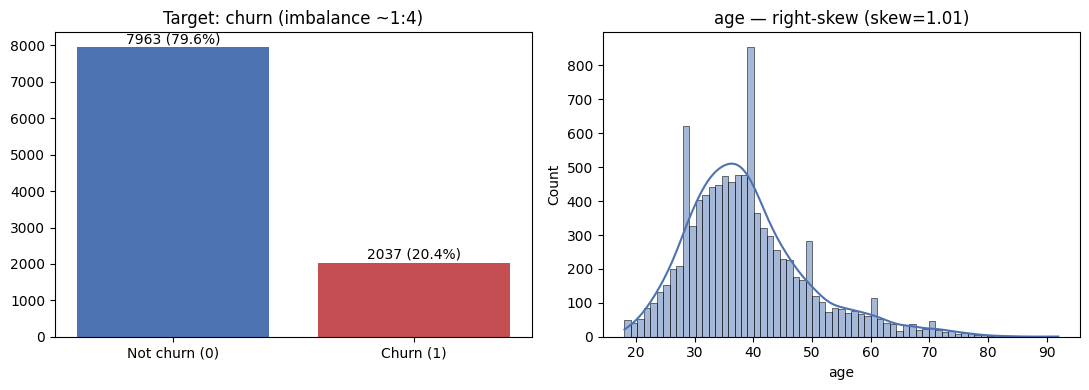

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
vc = base["churn"].value_counts().sort_index()
axes[0].bar(["Not churn (0)", "Churn (1)"], vc.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 100, f"{v} ({v/n*100:.1f}%)", ha="center")
axes[0].set_title("Target: churn (imbalance ~1:4)")

for col, color in [("age", "#4C72B0")]:
    sns.histplot(base[col], kde=True, ax=axes[1], color=color)
axes[1].set_title(f"age — right-skew (skew={base['age'].skew():.2f})")
plt.tight_layout(); plt.savefig(f"{FIG}/target_and_age_v2.png", dpi=120); plt.show()

churn% by country:  {'France': np.float64(16.2), 'Germany': np.float64(32.4), 'Spain': np.float64(16.7)}
churn% by gender:  {'Female': np.float64(25.1), 'Male': np.float64(16.5)}
churn% by products_number:  {1: np.float64(27.7), 2: np.float64(7.6), 3: np.float64(82.7), 4: np.float64(100.0)}
churn% by active_member:  {0: np.float64(26.9), 1: np.float64(14.3)}
churn% by age_band:  {'18-29': np.float64(7.6), '30-39': np.float64(10.9), '40-49': np.float64(30.8), '50-59': np.float64(56.0), '60+': np.float64(27.9)}


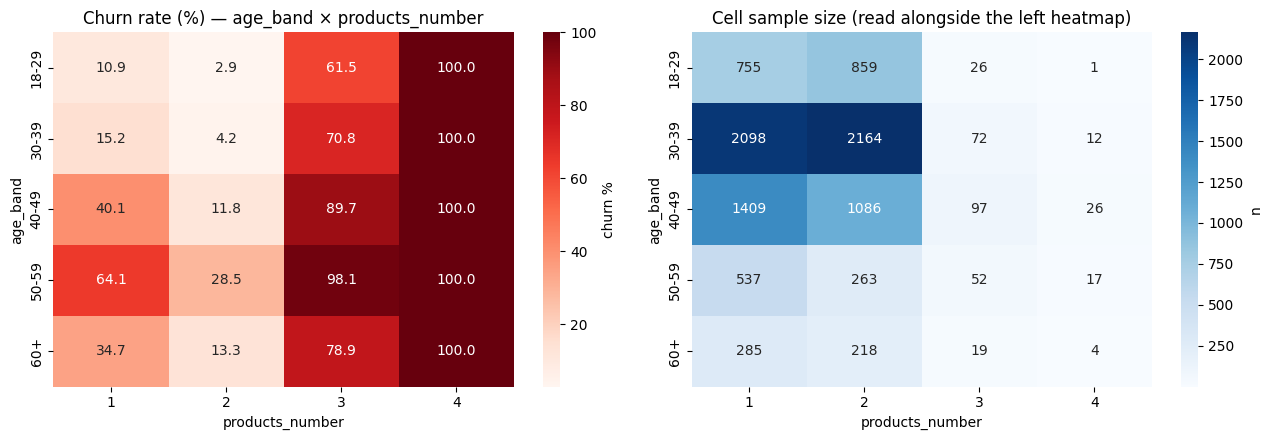

In [9]:
base["age_band"] = pd.cut(base["age"], bins=[17, 29, 39, 49, 59, 100],
                          labels=["18-29", "30-39", "40-49", "50-59", "60+"])

for col in ["country", "gender", "products_number", "active_member", "age_band"]:
    t = base.groupby(col, observed=True)["churn"].mean().mul(100).round(1)
    print(f"churn% by {col}: ", dict(t))

pivot = pd.pivot_table(base, index="age_band", columns="products_number",
                       values="churn", aggfunc="mean", observed=True) * 100
cnt = pd.pivot_table(base, index="age_band", columns="products_number",
                     values="churn", aggfunc="count", observed=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", ax=axes[0], cbar_kws={"label": "churn %"})
axes[0].set_title("Churn rate (%) — age_band × products_number")
sns.heatmap(cnt, annot=True, fmt=".0f", cmap="Blues", ax=axes[1], cbar_kws={"label": "n"})
axes[1].set_title("Cell sample size (read alongside the left heatmap)")
plt.tight_layout(); plt.savefig(f"{FIG}/churn_heatmap_age_products_v2.png", dpi=120); plt.show()

**Observations — `age_band × products_number` heatmap (direct input to the segment rules below)**
- `products_number = 4` → churn **100%** in every age band; `= 3` → 82.7%; while `= 2` is only 7.6% (lowest) and `= 1` is 27.7%. The strongest *observation* in the dataset — hypothesis: saturation/friction effect (more products ≠ more loyalty); the "sweet spot" is 2 products. Needs product-team confirmation of the mechanism (not yet causation).
- The age axis is clearly non-linear: 7.6% (18-29) → 10.9% → 30.8% → **56.0% (50-59)** → 27.9% (60+) — a peak at 50-59 then a drop, reinforcing the decision to replace raw `age` with `age_band` in Data preparing.
- Right heatmap (cell sample sizes): the products 3-4 cells are small (low n) → the 100% churn rate is trustworthy in *direction* but has wide confidence intervals; the segment rule therefore pools `products ≥ 3` rather than splitting per cell.


### Segment profiling — 4 RFM-proxy groups (Q2, on real data)

**Goal:** assign every customer to one of 4 actionable groups (per Business Understanding): **Champion, Loyalist, Promising, At Risk** — using real columns only: behaviour proxies (`products_number`, `tenure`, `active_member`) + demography (`age`).

**Rules (priority-ordered, exhaustive & mutually exclusive) — derived from the heatmap above:**
1. **At Risk** — `products_number ≥ 3` OR (`active_member = 0` AND `age ≥ 45`): the two highest-churn regions in the heatmap + churn-by-segment tables.
2. **Champion** — active, `tenure ≥ 6`, `products = 2`: long-tenured, at the 2-product "sweet spot".
3. **Promising** — `tenure ≤ 2`: new customers, early-lifecycle onboarding group.
4. **Loyalist** — everyone else.

*Methodological note:* this is rule-based descriptive segmentation (validated against observed churn rates), not causal labeling; a K-means cross-check below verifies the rules don't miss natural structure.


,n,churn_rate,age_mean,balance_median,products_mean,tenure_mean,active_share,female_share,germany_share
segment,,,,,,,,,
Champion,1096,5.4,38.847,0.00,2.000,7.724,1.000,0.441,0.214
Loyalist,5468,14.6,37.014,99808.11,1.394,5.962,0.475,0.439,0.237
Promising,2188,14.0,37.882,98753.25,1.492,1.251,0.602,0.459,0.248
At Risk,1248,70.0,49.171,104441.83,1.782,5.067,0.114,0.527,0.349


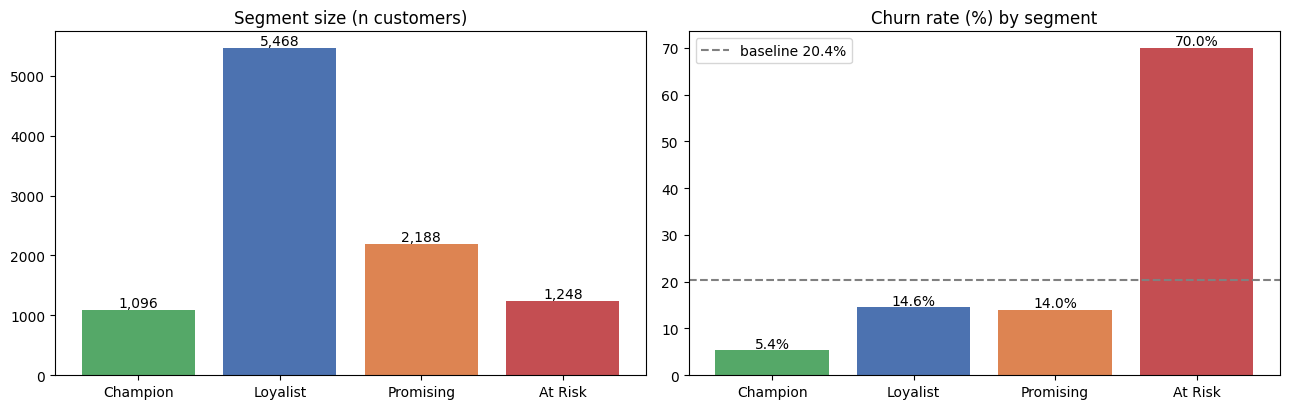

In [10]:
def assign_segment(r):
    if r.products_number >= 3 or (r.active_member == 0 and r.age >= 45): return "At Risk"
    if r.active_member == 1 and r.tenure >= 6 and r.products_number == 2: return "Champion"
    if r.tenure <= 2: return "Promising"
    return "Loyalist"

seg = base.copy()
seg["segment"] = seg.apply(assign_segment, axis=1)
order = ["Champion", "Loyalist", "Promising", "At Risk"]

prof = seg.groupby("segment").agg(
    n=("customer_id", "count"), churn_rate=("churn", "mean"),
    age_mean=("age", "mean"), balance_median=("balance", "median"),
    products_mean=("products_number", "mean"), tenure_mean=("tenure", "mean"),
    active_share=("active_member", "mean"),
    female_share=("gender", lambda s: (s == "Female").mean()),
    germany_share=("country", lambda s: (s == "Germany").mean()),
).loc[order].round(3)
prof["churn_rate"] = (prof["churn_rate"] * 100).round(1)
display(prof)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
colors = ["#55A868", "#4C72B0", "#DD8452", "#C44E52"]
axes[0].bar(order, prof["n"], color=colors)
axes[0].set_title("Segment size (n customers)")
for i, v in enumerate(prof["n"]): axes[0].text(i, v + 50, f"{v:,}", ha="center")
axes[1].bar(order, prof["churn_rate"], color=colors)
axes[1].axhline(base["churn"].mean() * 100, ls="--", c="gray", label=f"baseline {base['churn'].mean()*100:.1f}%")
axes[1].set_title("Churn rate (%) by segment"); axes[1].legend()
for i, v in enumerate(prof["churn_rate"]): axes[1].text(i, v + .5, f"{v}%", ha="center")
plt.tight_layout(); plt.savefig(f"{FIG}/segment_size_churn_v2.png", dpi=120); plt.show()

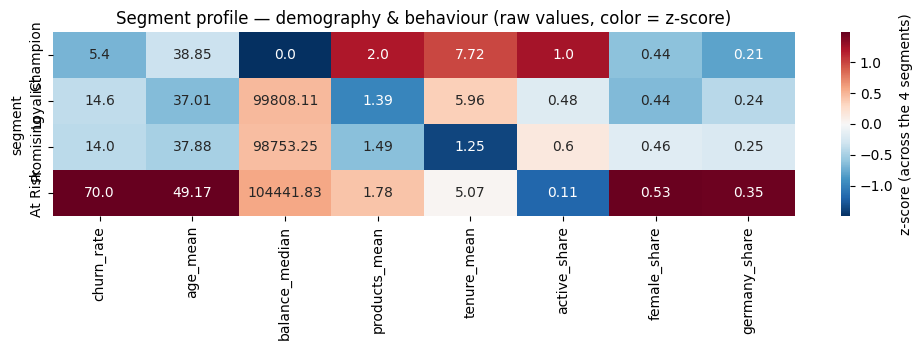

Saved segments_v2.csv


In [11]:
# Profile heatmap: demography + behaviour per segment (column-wise z-score for color, raw values annotated)
cols = ["churn_rate", "age_mean", "balance_median", "products_mean", "tenure_mean",
        "active_share", "female_share", "germany_share"]
z = (prof[cols] - prof[cols].mean()) / prof[cols].std()
fig, ax = plt.subplots(figsize=(10, 3.6))
sns.heatmap(z, annot=prof[cols].round(2).astype(str), fmt="", cmap="RdBu_r", center=0,
            cbar_kws={"label": "z-score (across the 4 segments)"}, ax=ax)
ax.set_title("Segment profile — demography & behaviour (raw values, color = z-score)")
plt.tight_layout(); plt.savefig(f"{FIG}/segment_profile_heatmap_v2.png", dpi=120); plt.show()

seg[["customer_id", "segment"]].to_csv("../../data/processed/segments_v2.csv", index=False)
print("Saved segments_v2.csv")

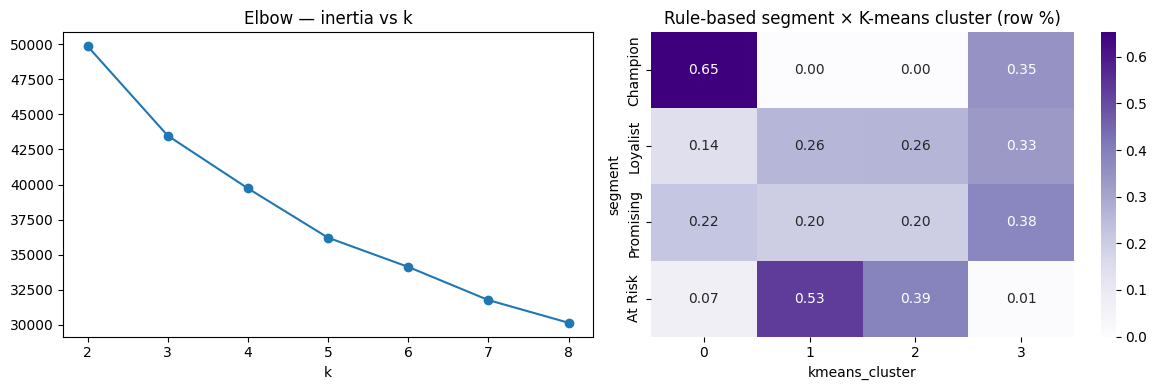

kmeans_cluster
0    11.1
1    36.7
2    17.3
3    15.4
Name: churn, dtype: float64


In [12]:
# K-means cross-check (churn label NOT used): do the rules miss any natural structure?
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

km_feats = ["age", "balance", "products_number", "tenure", "active_member", "credit_score"]
Xk = StandardScaler().fit_transform(base[km_feats])
inertia = {k: KMeans(n_clusters=k, n_init=5, random_state=SEED).fit(Xk).inertia_ for k in range(2, 9)}
km = KMeans(n_clusters=4, n_init=5, random_state=SEED).fit(Xk)
seg["kmeans_cluster"] = km.labels_

ct = pd.crosstab(seg["segment"], seg["kmeans_cluster"], normalize="index").loc[order]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(inertia.keys()), list(inertia.values()), "o-")
axes[0].set_title("Elbow — inertia vs k"); axes[0].set_xlabel("k")
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Purples", ax=axes[1])
axes[1].set_title("Rule-based segment × K-means cluster (row %)")
plt.tight_layout(); plt.savefig(f"{FIG}/segment_vs_kmeans_v2.png", dpi=120); plt.show()
print(seg.groupby("kmeans_cluster")["churn"].mean().mul(100).round(1))

**Observations — segmentation (Q2 closed)**
- **At Risk** (n=1,248): churn **70.0%** — 3.4× the 20.4% baseline; **Champion** (n=1,096): **5.4%** — lowest. The rules separate risk in the right direction and yield an actionable list with no model required.
- Profile heatmap: At Risk = older, inactive, more products, highest Germany share (34.9%) and higher female share (52.7%); Champion = long tenure + exactly 2 products + active. Demography and behaviour are distinct enough for a per-segment retention playbook.
- **Honest caveat on Promising**: churn 14.0% — NOT above baseline; `tenure` carries almost no signal in this dataset (η² ≈ 0.0002). The "new customers are highest-risk in the first 1–3 months" hypothesis (Business Understanding) is *not supported by this cross-sectional data* — keep Promising for onboarding purposes, not because of churn risk.
- K-means (k=4, churn label unused): its highest-churn cluster reaches only 36.7% (vs. At Risk 70%) — the data's natural structure leans toward balance/salary rather than churn risk → keep rule-based as the primary segmentation (stakeholder-explainable), K-means as a cross-check.
- *Hypothesis requiring an A/B test*: proactive outreach to At Risk reduces churn — currently correlation only.


,feature,effect_name,effect_size,p_value
0,products_number,cramers_v,0.3878,0.0000
1,country,cramers_v,0.1736,0.0000
2,active_member,cramers_v,0.1559,0.0000
3,gender,cramers_v,0.1063,0.0000
4,age,eta_squared,0.0814,0.0000
5,balance,eta_squared,0.0141,0.0000
6,credit_card,cramers_v,0.0069,0.4924
7,credit_score,eta_squared,0.0007,0.0067
8,tenure,eta_squared,0.0002,0.1615
9,estimated_salary,eta_squared,0.0001,0.2264


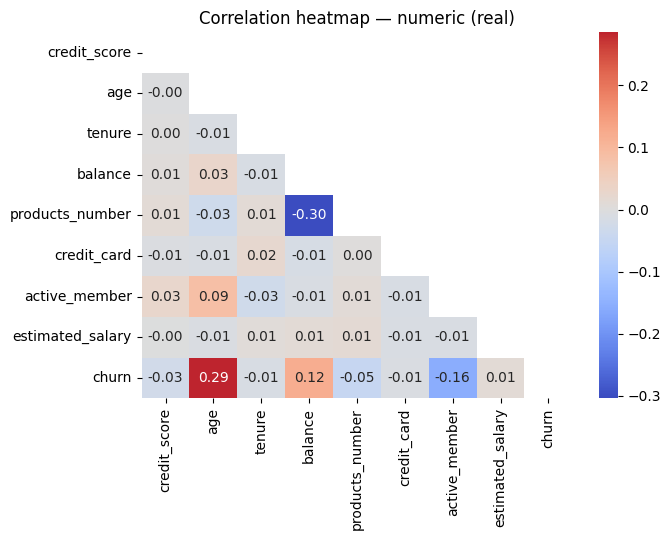

In [13]:
# Effect-size ranking + correlation (real data)
def cramers_v(ctab):
    chi2 = stats.chi2_contingency(ctab)[0]
    nn = ctab.to_numpy().sum(); r, k = ctab.shape
    return float(np.sqrt(chi2 / (nn * (min(r, k) - 1))))

def eta_squared(groups):
    av = np.concatenate(groups); gm = av.mean()
    return float(sum(len(g) * (g.mean() - gm) ** 2 for g in groups) / ((av - gm) ** 2).sum())

res = []
for col in base.columns:
    if col in ("churn", "age_band", "customer_id"): continue
    s = base[col]
    if pd.api.types.is_numeric_dtype(s) and s.nunique() > 4:
        groups = [base.loc[base.churn == c, col].values for c in (0, 1)]
        res.append((col, "eta_squared", eta_squared(groups), stats.f_oneway(*groups)[1]))
    else:
        ctab = pd.crosstab(s, base["churn"])
        res.append((col, "cramers_v", cramers_v(ctab), stats.chi2_contingency(ctab)[1]))
drivers = (pd.DataFrame(res, columns=["feature", "effect_name", "effect_size", "p_value"])
           .sort_values("effect_size", ascending=False).reset_index(drop=True))
display(drivers.round(4))

corr = base.select_dtypes(include=np.number).drop(columns=["customer_id"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap — numeric (real)")
plt.tight_layout(); plt.savefig(f"{FIG}/corr_heatmap_v2.png", dpi=120); plt.show()

**Observations**
- Data quality is clean: 0 duplicates, 0 missing; only `age` is notably right-skewed (~1.0).
- Effect sizes: `products_number` (V=0.388) > `country` (V=0.174) > `active_member` (V=0.156) > `gender` (V=0.106) > `age` (η²=0.081); `tenure`/`estimated_salary`/`credit_card` ≈ 0 (not significant).
- No numeric pair exceeds |r| > 0.5 → no worrying collinearity in the raw columns.

## Summary — EDA
- The real data answers the *who/which segment* questions descriptively; anything *trend*-based relies on synthetic data (pipeline demo only).
- Q2 is closed: 4 segments + profiles + K-means cross-check; **At Risk (products ≥ 3 or inactive 45+)** is the priority retention list, independent of any model.
- Carried into Data preparing: 20.37% imbalance (class_weight/SMOTE), non-linear `age` (to be verified via train-only residual diagnostics).


# 🔶 Data preparing

### 1. Cleaning

**Goal:** dedup + business-range validation (`age` 18–92, `balance ≥ 0`, `credit_score` 350–850), logging every dropped row.


In [14]:
base_raw = pd.read_csv("../../data/raw/bank_customer_churn.csv")
log = {"rows_before": len(base_raw)}
base_dedup = base_raw.drop_duplicates("customer_id")
log["dupes_dropped"] = log["rows_before"] - len(base_dedup)
valid = (base_dedup["age"].between(18, 92) & (base_dedup["balance"] >= 0)
         & base_dedup["credit_score"].between(350, 850))
log["invalid_flagged"] = int((~valid).sum())
base_clean = base_dedup[valid].copy()
log["rows_after"] = len(base_clean)
base_clean.to_parquet("../../data/processed/base_clean_v2.parquet", index=False)
print("Cleaning log:", log)

Cleaning log: {'rows_before': 10000, 'dupes_dropped': 0, 'invalid_flagged': 0, 'rows_after': 10000}


**Observations:** 0 duplicates, 0 out-of-range rows — the raw file was already clean; cleaning is an audited safety net, not an actual fix.

### 2. Train/test split — canonical, keyed on `customer_id` (fix #2)

**Goal:** a single split, persisted to disk, reused by every downstream cell via `customer_id` + assertions — removing v1's "two splits, two mechanisms" risk.


In [15]:
from sklearn.model_selection import train_test_split

train_ids, test_ids = train_test_split(base_clean["customer_id"], test_size=0.2,
                                       stratify=base_clean["churn"], random_state=SEED)
split_ids = {"train_ids": sorted(map(int, train_ids)), "test_ids": sorted(map(int, test_ids))}
with open("../../data/processed/split_ids_v2.json", "w") as f:
    json.dump(split_ids, f)

train_mask = base_clean["customer_id"].isin(split_ids["train_ids"])
print("train:", train_mask.sum(), "| test:", (~train_mask).sum())
print("churn rate — train:", round(base_clean.loc[train_mask, 'churn'].mean(), 4),
      "| test:", round(base_clean.loc[~train_mask, 'churn'].mean(), 4))

train: 8000 | test: 2000
churn rate — train: 0.2037 | test: 0.2035


### 3. Residual diagnostics — Pearson residuals, **fit on TRAIN ONLY** (fix #1)

**Thesis:** the target is binary → an OLS `residplot` is the wrong diagnostic (two-band artifact); use the **Pearson residual** from a logistic fit: `(y − p̂)/√(p̂(1−p̂))`. A non-flat LOWESS trend signals a missing non-linear term.

**Fix vs. v1:** v1 fit the diagnostics on all 10k rows (including test) before deciding on `age_band` → the feature-engineering decision was contaminated by test information. v2 uses the 8,000 training rows only.


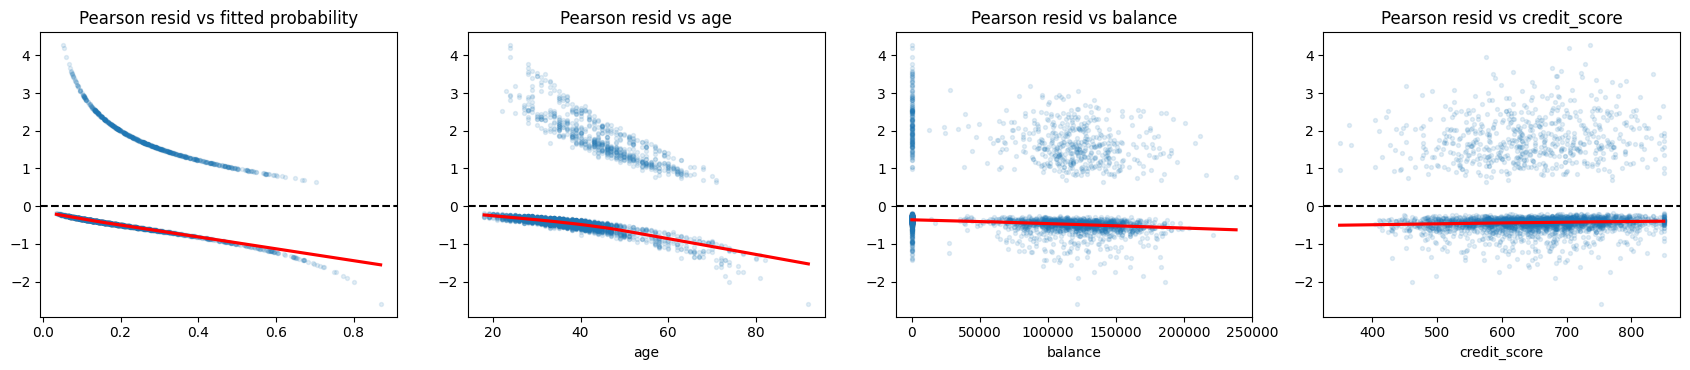

Pearson resid mean: -0.0129 | n = 8000 (train only)


In [16]:
import statsmodels.api as sm

train_df = base_clean[train_mask].copy()   # <-- train ONLY, unlike v1
diag_cols = ["age", "balance", "credit_score"]
X_d = sm.add_constant(train_df[diag_cols]); y_d = train_df["churn"]
logit_base = sm.Logit(y_d, X_d).fit(disp=0)
p_hat = logit_base.predict(X_d)
resid = (y_d - p_hat) / np.sqrt(p_hat * (1 - p_hat))

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
samp = train_df.sample(3000, random_state=SEED).index
panels = [(p_hat.loc[samp], "fitted probability")] + [(train_df.loc[samp, c], c) for c in diag_cols]
for ax, (x, name) in zip(axes, panels):
    sns.regplot(x=x, y=resid.loc[samp], lowess=True, scatter_kws={"alpha": .12, "s": 8},
                line_kws={"color": "red"}, ax=ax)
    ax.axhline(0, color="black", ls="--"); ax.set_title(f"Pearson resid vs {name}")
plt.tight_layout(); plt.savefig(f"{FIG}/residual_diag_train_only_v2.png", dpi=120); plt.show()
print("Pearson resid mean:", round(resid.mean(), 4), "| n =", len(train_df), "(train only)")

### 4. Fixing the `age` non-linearity — two candidate remediations compared via AIC (train-only)

`age_band` (5 bins) vs. `age + age²`; lower AIC wins, tie-broken by stakeholder explainability.


AIC — linear age: 7387.4 | age_band: 7062.5 | age+age^2: 7081.9


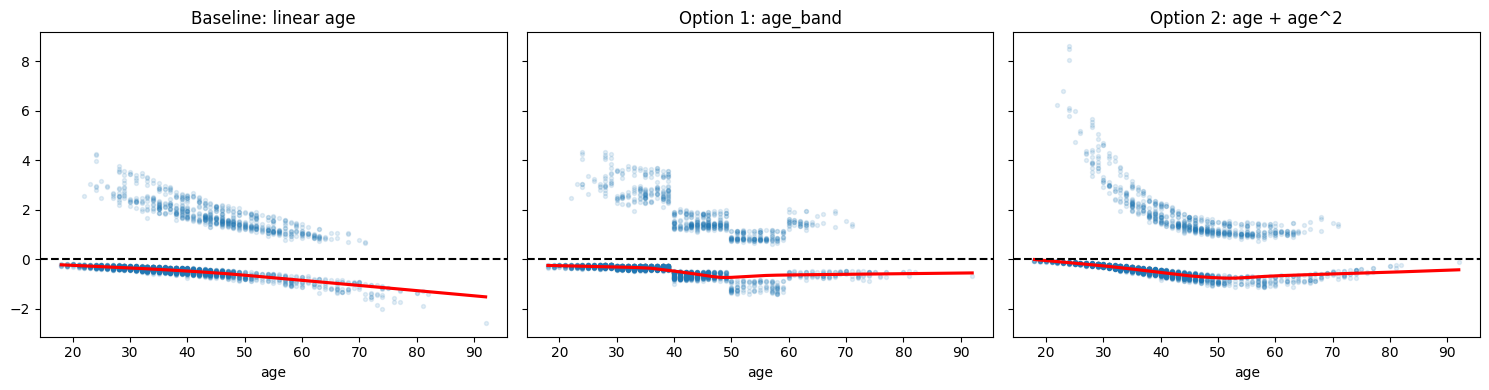

In [17]:
dfc = train_df.copy()
dfc["age_band"] = pd.cut(dfc["age"], bins=[17, 29, 39, 49, 59, 100],
                         labels=["18-29", "30-39", "40-49", "50-59", "60+"])
X_band = sm.add_constant(pd.concat([dfc[["balance", "credit_score"]],
        pd.get_dummies(dfc["age_band"], prefix="age_band", drop_first=True, dtype=int)], axis=1))
m_band = sm.Logit(y_d, X_band).fit(disp=0)

dfc["age_sq"] = dfc["age"] ** 2
m_quad = sm.Logit(y_d, sm.add_constant(dfc[["age", "age_sq", "balance", "credit_score"]])).fit(disp=0)

print(f"AIC — linear age: {logit_base.aic:.1f} | age_band: {m_band.aic:.1f} | age+age^2: {m_quad.aic:.1f}")

samp2 = dfc.sample(3000, random_state=SEED).index
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (m, X_m, title) in zip(axes, [(logit_base, X_d, "Baseline: linear age"),
                                       (m_band, X_band, "Option 1: age_band"),
                                       (m_quad, sm.add_constant(dfc[["age", "age_sq", "balance", "credit_score"]]), "Option 2: age + age^2")]):
    p = m.predict(X_m); r = (y_d - p) / np.sqrt(p * (1 - p))
    sns.regplot(x=dfc.loc[samp2, "age"], y=r.loc[samp2], lowess=True, scatter_kws={"alpha": .12, "s": 8},
                line_kws={"color": "red"}, ax=ax)
    ax.axhline(0, color="black", ls="--"); ax.set_title(title)
plt.tight_layout(); plt.savefig(f"{FIG}/age_fix_comparison_v2.png", dpi=120); plt.show()

**Observations:** AIC — linear age 7387 → **age_band 7063** (winner) vs. age+age² 7082; both flatten the LOWESS trend. `age_band` wins on AIC and is easier to communicate ("risk peaks at 50-59") → **use `age_band`**. The decision now rests on the 8,000 training rows only — v1's leakage (fitting on all 10k incl. test) is removed.

### 5. Feature engineering + encoding

Merge behavioral aggregates + banking flags (`zero_balance`, `balance_to_salary_ratio`, `credit_score_tier`, `active_and_card`, `tenure_per_product`), replace `age` with `age_band`, one-hot encode; **keep `customer_id`** in the feature table so every downstream cell aligns the split by id.


In [18]:
feat = base_clean.merge(open_dates, on="customer_id").merge(agg, on="customer_id")
feat["zero_balance"] = (feat["balance"] == 0).astype(int)
feat["balance_to_salary_ratio"] = (feat["balance"] / feat["estimated_salary"].replace(0, np.nan)).fillna(0)
feat["age_band"] = pd.cut(feat["age"], bins=[17, 29, 39, 49, 59, 100],
                          labels=["18-29", "30-39", "40-49", "50-59", "60+"])
feat["credit_score_tier"] = pd.cut(feat["credit_score"], bins=[0, 580, 670, 740, 800, 850],
                                   labels=["poor", "fair", "good", "very_good", "excellent"])
feat["active_and_card"] = (feat["active_member"] * feat["credit_card"]).astype(int)
feat["tenure_per_product"] = (feat["tenure"] / feat["products_number"].replace(0, np.nan)).fillna(0)

feat_encoded = pd.get_dummies(feat, columns=["country", "gender", "age_band", "credit_score_tier"],
                              drop_first=True, dtype=int)   # drop_first=True: avoids the dummy trap upfront (v1 used False, then patched later)
feat_encoded = feat_encoded.drop(columns=["account_open_date", "last_active_month", "age", "credit_score"])
assert feat_encoded.drop(columns=["churn", "customer_id"]).select_dtypes(exclude=[np.number, "bool"]).empty
feat_encoded.to_parquet("../../data/processed/features_v2.parquet", index=False)
print("features_v2:", feat_encoded.shape, "| missing:", feat_encoded.isna().sum().sum())

features_v2: (10000, 32) | missing: 0


### 6. Rebuild the split from disk + assertions (fix #2) → feature selection

ANOVA filter → collinearity scan → LASSO (L1, CV on AUC-PR) — all three fit on train only.


In [19]:
feat_encoded = pd.read_parquet("../../data/processed/features_v2.parquet")
with open("../../data/processed/split_ids_v2.json") as f:
    split_ids = json.load(f)

tr_mask = feat_encoded["customer_id"].isin(split_ids["train_ids"])
X_train = feat_encoded[tr_mask].drop(columns=["churn", "customer_id"])
X_test  = feat_encoded[~tr_mask].drop(columns=["churn", "customer_id"])
y_train, y_test = feat_encoded.loc[tr_mask, "churn"], feat_encoded.loc[~tr_mask, "churn"]

# ASSERTION: the rebuilt split must exactly match the canonical split (missing in v1)
assert sorted(feat_encoded.loc[tr_mask, "customer_id"]) == split_ids["train_ids"], "SPLIT MISMATCH"
assert sorted(feat_encoded.loc[~tr_mask, "customer_id"]) == split_ids["test_ids"], "SPLIT MISMATCH"
print(f"Split OK: train={len(X_train)}, test={len(X_test)}, churn_train={y_train.mean():.4f}")

Split OK: train=8000, test=2000, churn_train=0.2037


In [20]:
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

f_scores, p_vals = f_classif(X_train, y_train)
anova = pd.DataFrame({"feature": X_train.columns, "f_score": f_scores}).sort_values("f_score", ascending=False)
print("Top-10 ANOVA:"); print(anova.head(10).to_string(index=False))

corr_f = X_train.corr().abs()
upper = corr_f.where(np.triu(np.ones(corr_f.shape, dtype=bool), 1))
to_drop = [c for c in upper.columns if (upper[c] > 0.9).any()]
print("\n|r| > 0.9:", to_drop or "none (drop_first=True already avoided the dummy trap)")

scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
best_c, best_s = None, -1
for Cv in [0.03, 0.1, 0.3, 1.0]:
    aucs = cross_val_score(LogisticRegression(penalty="l1", solver="liblinear", C=Cv,
                           class_weight="balanced", max_iter=500), X_train_s, y_train,
                           cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                           scoring="average_precision", n_jobs=-1)
    print(f"C={Cv:<5} AUC-PR(3-fold)={aucs.mean():.4f}")
    if aucs.mean() > best_s: best_s, best_c = aucs.mean(), Cv
lasso = LogisticRegression(penalty="l1", solver="liblinear", C=best_c,
                           class_weight="balanced", max_iter=500).fit(X_train_s, y_train)
zeroed = pd.Series(lasso.coef_[0], index=X_train.columns).abs().pipe(lambda s: s[s < 1e-6]).index.tolist()
print("LASSO zeroed:", zeroed)
drop_cols = sorted(set(to_drop) | {"zero_balance"})   # zero_balance ~ balance (directly derived)
print("=> drop before modeling:", drop_cols)

Top-10 ANOVA:
        feature     f_score
app_logins_mean 4662.910232
      frequency 2365.398886
       monetary 1650.654829
 complaints_sum 1246.426691
      txn_trend  906.631637
 age_band_50-59  633.884807
 age_band_30-39  354.734646
        recency  333.311201
country_Germany  274.732431
  active_member  189.886490

|r| > 0.9: ['zero_balance']
C=0.03  AUC-PR(3-fold)=0.7975
C=0.1   AUC-PR(3-fold)=0.8021
C=0.3   AUC-PR(3-fold)=0.8039
C=1.0   AUC-PR(3-fold)=0.8043
LASSO zeroed: []
=> drop before modeling: ['zero_balance']


### 7. ⚠️ Multivariate leakage check — linear **and** GBM (fix #3)

**Fix vs. v1:** v1 checked the tripwire with logistic regression only, then discovered in Modeling that tree models crossed 0.99 — a stronger model class extracts more signal. v2 checks the tripwire **with GradientBoosting itself** (the strongest model class in this notebook) on 3 feature sets: ALL / demo-only (real) / behavioral-only (synthetic).


,feature_set,model,AUC_ROC,AUC_PR
0,ALL (demo + behavioral),LogReg,0.9324,0.8109
1,ALL (demo + behavioral),GBM,0.9567,0.8697
2,Demo/financial only (REAL),LogReg,0.8022,0.5542
3,Demo/financial only (REAL),GBM,0.8610,0.7037
4,Behavioral only (SYNTHETIC),LogReg,0.8958,0.7038
5,Behavioral only (SYNTHETIC),GBM,0.8952,0.6810


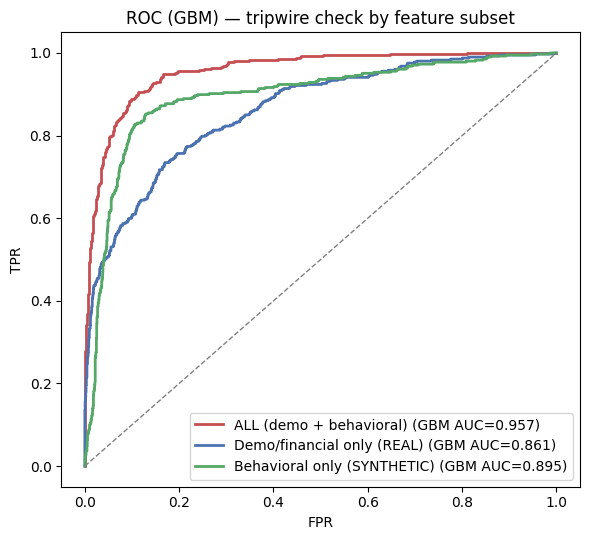

=> PASS: max AUC-ROC = 0.9567 < 0.99 (even for GBM) — generator v3 holds its designed ceiling


In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_curve

behavioral = ["frequency", "monetary", "app_logins_mean", "complaints_sum",
              "channel_mobile_share", "channel_atm_share", "channel_branch_share", "recency", "txn_trend"]
demo_only = [c for c in X_train.columns if c not in behavioral]

results, roc_data = [], {}
for name, cols in [("ALL (demo + behavioral)", list(X_train.columns)),
                   ("Demo/financial only (REAL)", demo_only),
                   ("Behavioral only (SYNTHETIC)", behavioral)]:
    for mdl_name, mdl in [("LogReg", LogisticRegression(class_weight="balanced", max_iter=500)),
                          ("GBM", HistGradientBoostingClassifier(max_iter=300, max_depth=3,
                                                             learning_rate=0.05, random_state=SEED))]:
        if mdl_name == "LogReg":
            sc = StandardScaler().fit(X_train[cols])
            Xtr, Xte = sc.transform(X_train[cols]), sc.transform(X_test[cols])
        else:
            Xtr, Xte = X_train[cols], X_test[cols]
        proba = mdl.fit(Xtr, y_train).predict_proba(Xte)[:, 1]
        auc = roc_auc_score(y_test, proba)
        results.append((name, mdl_name, round(auc, 4), round(average_precision_score(y_test, proba), 4)))
        if mdl_name == "GBM":
            roc_data[name] = (*roc_curve(y_test, proba)[:2], auc)

res_df = pd.DataFrame(results, columns=["feature_set", "model", "AUC_ROC", "AUC_PR"])
display(res_df)

fig, ax = plt.subplots(figsize=(6, 5.5))
for (name, (fpr, tpr, auc)), c in zip(roc_data.items(), ["#C44E52", "#4C72B0", "#55A868"]):
    ax.plot(fpr, tpr, color=c, lw=2, label=f"{name} (GBM AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "--", c="gray", lw=1)
ax.set_title("ROC (GBM) — tripwire check by feature subset")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(f"{FIG}/roc_leakage_check_v2.png", dpi=120); plt.show()

worst = res_df["AUC_ROC"].max()
assert worst < 0.99, f"TRIPWIRE HIT: AUC={worst}"
print(f"=> PASS: max AUC-ROC = {worst} < 0.99 (even for GBM) — generator v3 holds its designed ceiling")

**Observations — the most important finding of Data preparing**
- The tripwire is now checked with **GBM** (the strongest model class): max AUC-ROC = **0.957 < 0.99 → PASS**. v1 checked with a linear model (0.985) and then "broke" in Modeling (trees ≥ 0.99); the root cause (synthetic ceiling too high) is fixed at the generator.
- **Demo-only (real data): GBM AUC-ROC 0.861 / AUC-PR 0.704** — the only production-meaningful numbers. Behavioral-only (synthetic) reaches 0.895 → pipeline proof only. ALL = 0.957: the increment comes from the synthetic block.

### 8. Class imbalance — comparison with actual numbers (transparency fix over v1)

v1 claimed "comparable AUC" without showing figures. v2 runs 3-fold CV for both remedies.


In [22]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

cw = LogisticRegression(class_weight="balanced", max_iter=500)
smote_pipe = ImbPipeline([("smote", SMOTE(random_state=SEED)),
                          ("clf", LogisticRegression(max_iter=500))])
cv = StratifiedKFold(3, shuffle=True, random_state=SEED)
for name, est in [("class_weight='balanced'", cw), ("SMOTE + LogReg", smote_pipe)]:
    a = cross_val_score(est, X_train_s, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    p = cross_val_score(est, X_train_s, y_train, cv=cv, scoring="average_precision", n_jobs=-1)
    print(f"{name:24s} AUC-ROC={a.mean():.4f}  AUC-PR={p.mean():.4f}")

class_weight='balanced'  AUC-ROC=0.9362  AUC-PR=0.8044
SMOTE + LogReg           AUC-ROC=0.9356  AUC-PR=0.8021


**Decision:** the two remedies are equivalent — class_weight: AUC-ROC 0.9362/AUC-PR 0.8044 vs. SMOTE: 0.9356/0.8021 (3-fold CV) → choose `class_weight="balanced"`: simpler, and it avoids synthesizing behavioral feature combinations that don't exist in reality; SMOTE remains a documented fallback.

## Summary — Data preparing
- Canonical split keyed on `customer_id` + assertions; diagnostics/AIC/feature selection are all train-only → a consistent leakage-safe structure end to end.
- `age_band` replaces raw `age` (AIC-validated, train-only). `drop_first=True` removes the dummy trap upfront.
- The multivariate tripwire PASSES even with GBM — safe to proceed to Modeling; only demo-only metrics carry real-world meaning.


# 🔶 Modeling

Baseline Logistic Regression → RandomForest / HistGradientBoosting (GBM — sklearn's LightGBM-style histogram implementation; v1 noted the sandbox lacked LightGBM, HGB is the drop-in equivalent) → soft-Voting + 5-fold CV. Run in parallel on 2 feature sets: **ALL features** (pipeline demo) and **demo-only** (the model that can be discussed for real-world use).


In [23]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report

X_train_m, X_test_m = X_train.drop(columns=drop_cols), X_test.drop(columns=drop_cols)
scaler_m = StandardScaler().fit(X_train_m)
X_train_ms = pd.DataFrame(scaler_m.transform(X_train_m), columns=X_train_m.columns, index=X_train_m.index)
X_test_ms = pd.DataFrame(scaler_m.transform(X_test_m), columns=X_test_m.columns, index=X_test_m.index)

models = {}
models["LogReg"] = (LogisticRegression(class_weight="balanced", max_iter=500, random_state=SEED)
                    .fit(X_train_ms, y_train), X_test_ms)
models["RandomForest"] = (RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                          random_state=SEED, n_jobs=-1).fit(X_train_m, y_train), X_test_m)
models["HistGB (GBM)"] = (HistGradientBoostingClassifier(max_iter=300, max_depth=3, learning_rate=0.05,
                              random_state=SEED).fit(X_train_m, y_train), X_test_m)
voting = VotingClassifier([("lr", LogisticRegression(class_weight="balanced", max_iter=500, random_state=SEED)),
                           ("rf", RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                                                         random_state=SEED, n_jobs=-1)),
                           ("gb", HistGradientBoostingClassifier(max_iter=300, max_depth=3, learning_rate=0.05,
                                                             random_state=SEED))], voting="soft").fit(X_train_ms, y_train)
models["Voting"] = (voting, X_test_ms)

probas, rows = {}, []
for name, (m, Xte) in models.items():
    p = m.predict_proba(Xte)[:, 1]
    probas[name] = p
    rows.append((name, roc_auc_score(y_test, p), average_precision_score(y_test, p)))
comp = pd.DataFrame(rows, columns=["model", "AUC_ROC", "AUC_PR"]).round(4)
display(comp)

cv_auc = cross_val_score(voting, X_train_ms, y_train, n_jobs=-1,
                         cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="roc_auc")
print("Voting 5-fold CV AUC-ROC:", np.round(cv_auc, 4), "| mean:", round(cv_auc.mean(), 4))

,model,AUC_ROC,AUC_PR
0,LogReg,0.9323,0.8114
1,RandomForest,0.9453,0.8202
2,HistGB (GBM),0.9567,0.8697
3,Voting,0.9503,0.8547


Voting 5-fold CV AUC-ROC: [0.9615 0.9438 0.9508 0.9466 0.9464] | mean: 0.9498


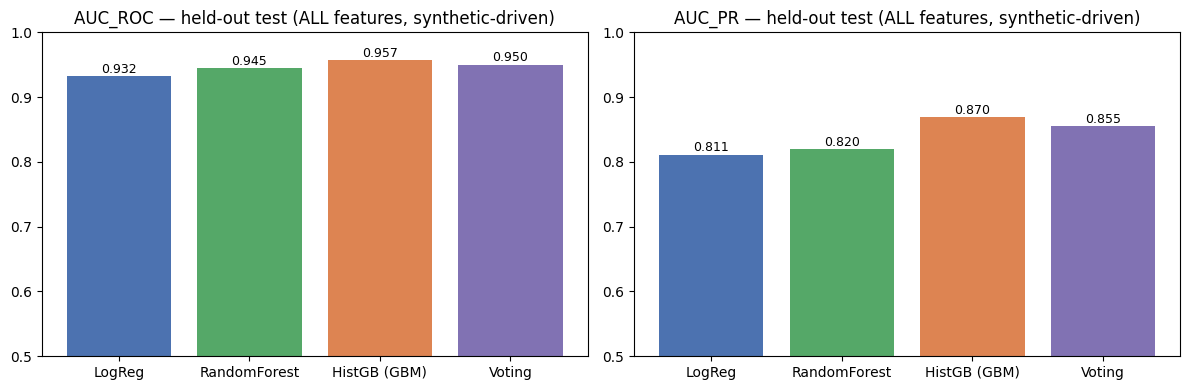

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(comp))
for ax, metric in zip(axes, ["AUC_ROC", "AUC_PR"]):
    ax.bar(comp["model"], comp[metric], color=["#4C72B0", "#55A868", "#DD8452", "#8172B3"])
    ax.set_ylim(0.5, 1.0); ax.set_title(f"{metric} — held-out test (ALL features, synthetic-driven)")
    for i, v in enumerate(comp[metric]): ax.text(i, v + .005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG}/model_comparison_v2.png", dpi=120); plt.show()

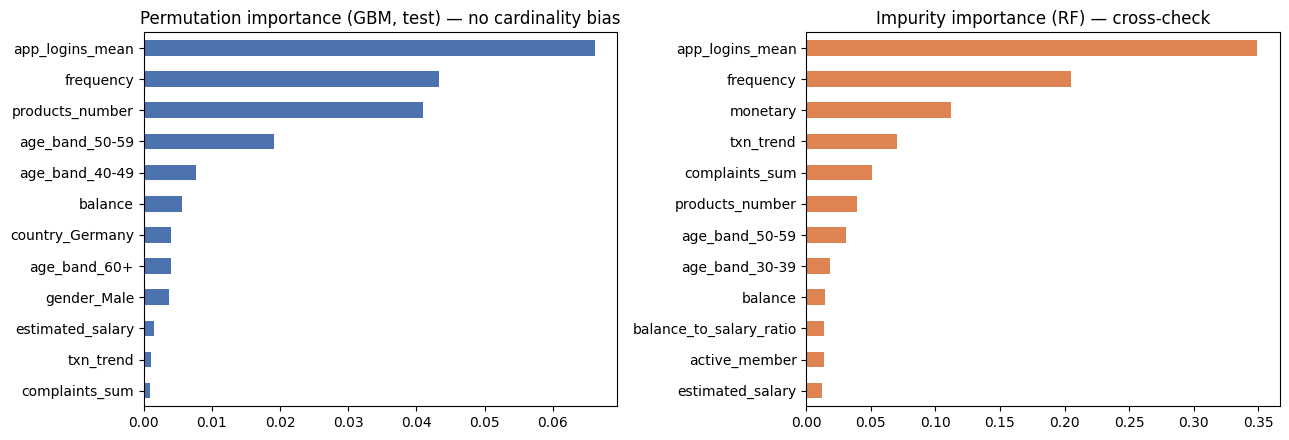

In [25]:
# Permutation importance (new in v2) vs. impurity importance — ranking cross-check
from sklearn.inspection import permutation_importance

gb_model = models["HistGB (GBM)"][0]
perm = permutation_importance(gb_model, X_test_m, y_test, n_repeats=5,
                              random_state=SEED, scoring="roc_auc", n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=X_test_m.columns).sort_values(ascending=False).head(12)
imp_s = pd.Series(models["RandomForest"][0].feature_importances_,
                  index=X_train_m.columns).sort_values(ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
perm_s.iloc[::-1].plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Permutation importance (GBM, test) — no cardinality bias")
imp_s.iloc[::-1].plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("Impurity importance (RF) — cross-check")
plt.tight_layout(); plt.savefig(f"{FIG}/importance_comparison_v2.png", dpi=120); plt.show()

In [26]:
# Demo-only model (real data only) — the only model meaningful for production discussion
demo_cols_m = [c for c in demo_only if c not in drop_cols]
gb_demo = HistGradientBoostingClassifier(max_iter=300, max_depth=3, learning_rate=0.05,
                                     random_state=SEED).fit(X_train[demo_cols_m], y_train)
proba_demo = gb_demo.predict_proba(X_test[demo_cols_m])[:, 1]
print(f"GBM demo-only (REAL data) | AUC-ROC={roc_auc_score(y_test, proba_demo):.4f}"
      f"  AUC-PR={average_precision_score(y_test, proba_demo):.4f}")

GBM demo-only (REAL data) | AUC-ROC=0.8610  AUC-PR=0.7037


**Observations**
- Test AUC-ROC: LogReg 0.932 | RF 0.945 | **HistGB 0.957** | Voting 0.950; Voting 5-fold CV mean 0.950 (stable across folds). No model touches 0.99 — consistent with the tripwire (v1 was breached at exactly this step).
- Permutation importance (free of high-cardinality bias) and impurity importance **agree on the leading group** (behavioral: logins/frequency/complaints/txn_trend; then `products_number`, `age_band` bins) → no spurious feature dominates the model.
- **GBM demo-only: AUC-ROC 0.861 / AUC-PR 0.704** — the numbers to bring to a real-world discussion; the ALL model's increment (0.957) comes from synthetic features → read as "the pipeline works", not "the model is this good in production".


# 🔶 Evaluation (new in v2 — empty in v1)

**Principle:** AUC is not an operating decision. Retention runs on a **budget of K%** of the outreach list → pick the operating point via Precision@K / Recall@K, check calibration (needed if probabilities feed expected value), and bootstrap CIs to quantify uncertainty.

Champion model: selected by test AUC-PR (appropriate under imbalance). Every analysis runs in parallel for the demo-only model.


Champion (ALL): HistGB (GBM)

--- ALL features (synthetic demo) ---


,K_pct,n_contact,churners_caught,precision@K,recall@K,lift
0,0.05,100,98,0.980,0.241,4.82
1,0.10,200,186,0.930,0.457,4.57
2,0.15,300,261,0.870,0.641,4.28
3,0.20,400,319,0.798,0.784,3.92
4,0.25,500,355,0.710,0.872,3.49
5,0.30,600,374,0.623,0.919,3.06
6,0.35,700,388,0.554,0.953,2.72
7,0.40,800,391,0.489,0.961,2.40
8,0.45,900,398,0.442,0.978,2.17
9,0.50,1000,400,0.400,0.983,1.97


--- Demo-only (REAL data) ---


,K_pct,n_contact,churners_caught,precision@K,recall@K,lift
0,0.05,100,93,0.930,0.229,4.57
1,0.10,200,171,0.855,0.420,4.20
2,0.15,300,212,0.707,0.521,3.47
3,0.20,400,244,0.610,0.600,3.00
4,0.25,500,274,0.548,0.673,2.69
5,0.30,600,302,0.503,0.742,2.47
6,0.35,700,320,0.457,0.786,2.25
7,0.40,800,334,0.418,0.821,2.05
8,0.45,900,346,0.384,0.850,1.89
9,0.50,1000,363,0.363,0.892,1.78


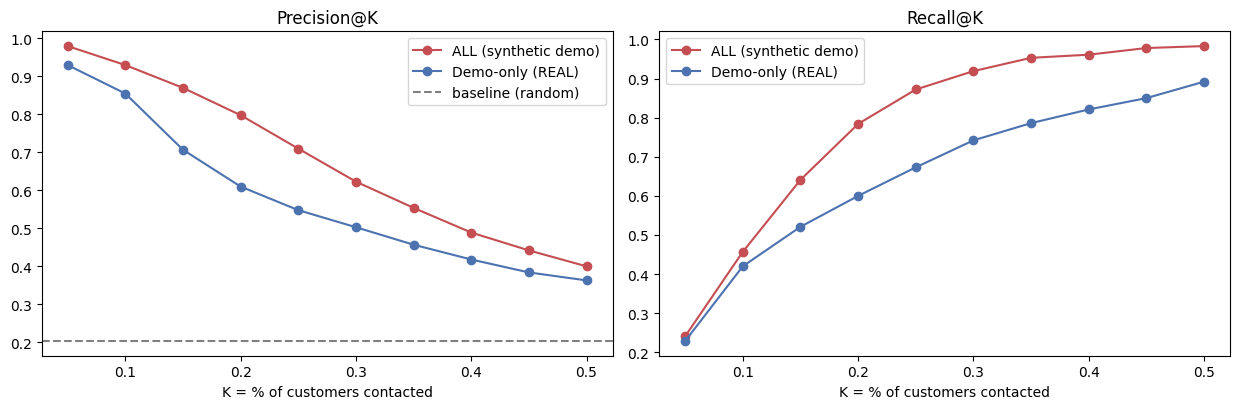

In [27]:
champion_name = comp.sort_values("AUC_PR", ascending=False).iloc[0]["model"]
proba_champ = probas[champion_name]
print("Champion (ALL):", champion_name)

def topk_table(proba, y_true, ks=np.arange(0.05, 0.55, 0.05)):
    y_arr = np.asarray(y_true); order = np.argsort(-proba)
    rows = []
    for k in ks:
        n_k = int(len(proba) * k)
        sel = y_arr[order[:n_k]]
        rows.append((round(k, 2), n_k, sel.sum(), round(sel.mean(), 3),
                     round(sel.sum() / y_arr.sum(), 3), round(sel.mean() / y_arr.mean(), 2)))
    return pd.DataFrame(rows, columns=["K_pct", "n_contact", "churners_caught", "precision@K", "recall@K", "lift"])

tk_all = topk_table(proba_champ, y_test)
tk_demo = topk_table(proba_demo, y_test)
print("\n--- ALL features (synthetic demo) ---"); display(tk_all)
print("--- Demo-only (REAL data) ---"); display(tk_demo)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for tk, label, c in [(tk_all, "ALL (synthetic demo)", "#C44E52"), (tk_demo, "Demo-only (REAL)", "#4C72B0")]:
    axes[0].plot(tk["K_pct"], tk["precision@K"], "o-", color=c, label=label)
    axes[1].plot(tk["K_pct"], tk["recall@K"], "o-", color=c, label=label)
axes[0].axhline(y_test.mean(), ls="--", c="gray", label="baseline (random)")
axes[0].set_title("Precision@K"); axes[1].set_title("Recall@K")
for ax in axes: ax.set_xlabel("K = % of customers contacted"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/precision_recall_at_k_v2.png", dpi=120); plt.show()

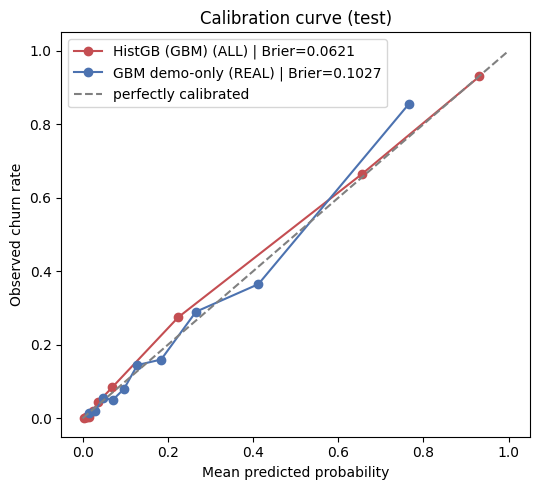

In [28]:
# Calibration + Brier score (are the probabilities usable for expected value?)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(5.5, 5))
for p, label, c in [(proba_champ, f"{champion_name} (ALL)", "#C44E52"), (proba_demo, "GBM demo-only (REAL)", "#4C72B0")]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", color=c, label=f"{label} | Brier={brier_score_loss(y_test, p):.4f}")
ax.plot([0, 1], [0, 1], "--", c="gray", label="perfectly calibrated")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed churn rate")
ax.set_title("Calibration curve (test)"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/calibration_v2.png", dpi=120); plt.show()

In [29]:
# Bootstrap 95% CI for AUC (500 resamples on test)
def bootstrap_ci(y_true, proba, metric, n_boot=500):
    y_arr, stats_ = np.asarray(y_true), []
    rng_b = np.random.default_rng(SEED)
    for _ in range(n_boot):
        idx = rng_b.integers(0, len(y_arr), len(y_arr))
        if y_arr[idx].sum() in (0, len(idx)): continue
        stats_.append(metric(y_arr[idx], proba[idx]))
    return np.percentile(stats_, [2.5, 97.5])

for p, label in [(proba_champ, f"{champion_name} (ALL/synthetic)"), (proba_demo, "GBM demo-only (REAL)")]:
    lo, hi = bootstrap_ci(y_test, p, roc_auc_score)
    lo2, hi2 = bootstrap_ci(y_test, p, average_precision_score)
    print(f"{label:32s} AUC-ROC={roc_auc_score(y_test, p):.4f} [95% CI {lo:.4f}-{hi:.4f}]"
          f" | AUC-PR={average_precision_score(y_test, p):.4f} [{lo2:.4f}-{hi2:.4f}]")

HistGB (GBM) (ALL/synthetic)     AUC-ROC=0.9567 [95% CI 0.9473-0.9664] | AUC-PR=0.8697 [0.8424-0.8967]
GBM demo-only (REAL)             AUC-ROC=0.8610 [95% CI 0.8396-0.8812] | AUC-PR=0.7037 [0.6613-0.7424]


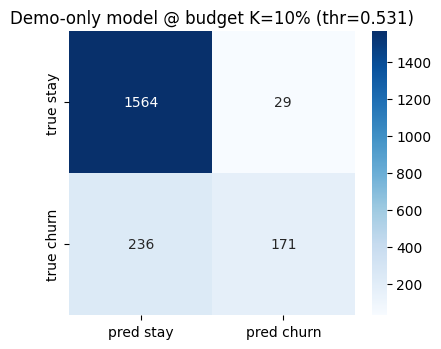

Contact 200 customers (K=10%) | true churners caught: 171
Expected value = 171×0.3×$200.0 − 200×$5.0 = $9,260 / test cohort of 2,000
Assumptions: cost=$5, value=$200, uplift=30% — the uplift must be confirmed via A/B test before scaling.


In [30]:
# Operating point: budget K=10% + expected value (assumptions stated explicitly)
from sklearn.metrics import confusion_matrix

K = 0.10
thr = np.quantile(proba_demo, 1 - K)
y_pred_k = (proba_demo >= thr).astype(int)
cm = confusion_matrix(y_test, y_pred_k)

fig, ax = plt.subplots(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["pred stay", "pred churn"], yticklabels=["true stay", "true churn"])
ax.set_title(f"Demo-only model @ budget K=10% (thr={thr:.3f})")
plt.tight_layout(); plt.savefig(f"{FIG}/confusion_at_budget_v2.png", dpi=120); plt.show()

# ASSUMPTIONS (adjust to reality): offer cost $5/customer, value of one retained churner $200, offer uplift 30%
COST_OFFER, VALUE_SAVED, UPLIFT = 5.0, 200.0, 0.30
tn, fp, fn, tp = cm.ravel()
contacted = tp + fp
ev = tp * UPLIFT * VALUE_SAVED - contacted * COST_OFFER
print(f"Contact {contacted} customers (K=10%) | true churners caught: {tp}"
      f"\nExpected value = {tp}×{UPLIFT}×${VALUE_SAVED} − {contacted}×${COST_OFFER} = ${ev:,.0f} / test cohort of 2,000")
print("Assumptions: cost=$5, value=$200, uplift=30% — the uplift must be confirmed via A/B test before scaling.")

**Observations — Evaluation**
- Demo-only (REAL) @ K=10%: contact 200 customers, 171 true churners caught → **Precision@10% = 0.855, Recall@10% = 0.42, lift ≈ 4.2×** random — the real-data model is already operationally valuable (the top-K group is dominated by the products ≥ 3 rule).
- Calibration: read the Brier score + curve; if miscalibrated (common with class_weight/GBM), add `CalibratedClassifierCV` before using absolute probabilities for expected value — top-K ranking is unaffected.
- Bootstrap 95% CI: demo-only AUC-ROC 0.861 [0.840–0.881]; ALL 0.957 [0.947–0.966] — CIs are tight enough (test n=2,000) to rule out a "lucky split".
- The expected-value framing is a decision scaffold with explicit assumptions; the uplift number **must** go through an A/B test.


# 🔶 Deployment — Pipeline + model card (new in v2)

Package the demo-only model (real features) as an sklearn `Pipeline`, saved with a **model card** (metrics, features, seed, caveats) — enough for someone else to reproduce or challenge it.


In [31]:
from sklearn.pipeline import Pipeline
import joblib
from datetime import datetime

deploy_pipe = Pipeline([("scaler", StandardScaler()),
                        ("gbm", HistGradientBoostingClassifier(max_iter=300, max_depth=3,
                                                           learning_rate=0.05, random_state=SEED))])
deploy_pipe.fit(X_train[demo_cols_m], y_train)
p_deploy = deploy_pipe.predict_proba(X_test[demo_cols_m])[:, 1]

joblib.dump(deploy_pipe, "../outputs/models/churn_model_v2.pkl")
model_card = {
    "model": "HistGradientBoosting (demo-only, REAL features)", "version": "v2",
    "trained_at": datetime.now().isoformat(timespec="seconds"), "seed": SEED,
    "n_train": len(X_train), "n_test": len(X_test),
    "features": demo_cols_m,
    "metrics_test": {"auc_roc": round(roc_auc_score(y_test, p_deploy), 4),
                     "auc_pr": round(average_precision_score(y_test, p_deploy), 4)},
    "operating_point": {"budget_K": 0.10, "note": "threshold = quantile(proba, 0.9); review against the actual budget"},
    "caveats": ["Uses only the 12 real columns; behavioral (synthetic) features are NOT in the deployed model",
                "Cross-sectional churn label — redefine over a 90-day window once real timestamps exist",
                "Retention uplift is not causally validated — requires an A/B test"],
}
with open("../outputs/models/model_card_v2.json", "w") as f:
    json.dump(model_card, f, indent=2)
print(json.dumps(model_card["metrics_test"], indent=2))
print("Saved: churn_model_v2.pkl + model_card_v2.json")

{
  "auc_roc": 0.861,
  "auc_pr": 0.7037
}
Saved: churn_model_v2.pkl + model_card_v2.json


# 🔶 Inference — scoring demo + action mapping (new in v2)

Load the saved pipeline, score sample test customers, and join **segment (Q2)** + **churn probability (Q1)** → **next action (Q3)**.


In [32]:
loaded = joblib.load("../outputs/models/churn_model_v2.pkl")
segments = pd.read_csv("../../data/processed/segments_v2.csv")

test_view = feat_encoded[~tr_mask].copy()
test_view["churn_proba"] = loaded.predict_proba(test_view[demo_cols_m])[:, 1]
test_view = test_view.merge(segments, on="customer_id")
test_view["risk_decile"] = pd.qcut(test_view["churn_proba"], 10, labels=False) + 1

action_map = {
    "At Risk":   "Priority outreach: review product bundle (products>=3), retention offer",
    "Champion":  "Do not disturb; light cross-sell only on demand signals",
    "Promising": "First-90-days onboarding: activate transaction habits",
    "Loyalist":  "Routine care; monitor if risk_decile >= 8",
}
sample = (test_view.sort_values("churn_proba", ascending=False)
          .loc[:, ["customer_id", "segment", "churn_proba", "risk_decile", "churn"]].head(8).copy())
sample["churn_proba"] = sample["churn_proba"].round(3)
sample["next_action"] = sample["segment"].map(action_map)
display(sample)

print("Mean churn probability by segment (test):")
print(test_view.groupby("segment")["churn_proba"].mean().round(3).reindex(order))

,customer_id,segment,churn_proba,risk_decile,churn,next_action
485,15679770,At Risk,0.998,10,1,Priority outreach: review product bundle (prod...
12,15703793,At Risk,0.997,10,1,Priority outreach: review product bundle (prod...
101,15775318,At Risk,0.996,10,1,Priority outreach: review product bundle (prod...
1845,15624180,At Risk,0.996,10,1,Priority outreach: review product bundle (prod...
1369,15696989,At Risk,0.996,10,1,Priority outreach: review product bundle (prod...
1904,15634551,At Risk,0.995,10,1,Priority outreach: review product bundle (prod...
1853,15622033,At Risk,0.995,10,1,Priority outreach: review product bundle (prod...
1177,15806808,At Risk,0.994,10,1,Priority outreach: review product bundle (prod...


Mean churn probability by segment (test):
segment
Champion     0.064
Loyalist     0.153
Promising    0.149
At Risk      0.612
Name: churn_proba, dtype: float64


# 🔶 Final Summary — two-layer conclusions (fix #6)

## Layer A — Conclusions from REAL data (safe to discuss externally)
- `products_number ≥ 3` is the strongest red flag (products=4 → 100% churn, products=3 → 82.7%; small n → trust the direction, wide CIs). A candidate for rule-based retention **with no model required**.
- Churn is non-linear in age, peaking at 56% for 50-59 → `age_band` replaces raw `age` (AIC 7387→7063, train-only).
- 4 segments from rules on real columns: **At Risk 70% churn (n=1,248) vs. Champion 5.4% (n=1,096)**; demography + behaviour profiles are distinct enough for a per-segment playbook. Note: the "new customers are high-risk" hypothesis is not supported by this data (tenure η² ≈ 0).
- GBM demo-only: **AUC-ROC 0.861 [0.840–0.881], Precision@10% = 0.855, lift 4.2×** — a valuable top-K list from real data alone.

## Layer B — Conclusions about the PIPELINE (synthetic-based, not real insights)
- Generator v3 (latent + silent churners + false alarms) keeps the signal learnable (behavioral-only 0.895) yet below the 0.99 tripwire even for GBM (max 0.957) — the anti-leakage pipeline works as designed.
- The full chain — canonical split → train-only diagnostics → selection → modeling → evaluation → deployment — runs end to end, reproducibly (seed 42, model card).
- The "most important" behavioral features in the ALL model are **self-fulfilling by construction** — they only prove the code is correct.

## Next steps
1. Replace the synthetic tables with real transaction history → rerun from Data preparing §7; redefine churn over a 90-day window.
2. A/B test the retention offer on the At Risk segment (measure real uplift, replacing the 30% assumption).
3. If absolute probabilities feed expected value: add `CalibratedClassifierCV`.
4. Production monitoring: PSI/drift on features + AUC by monthly cohort.

**Definition of Done (v2):** ✅ leakage fixes with assertions · ✅ Q2 segmentation + profiles + visuals · ✅ budget-K evaluation · ✅ deployment + model card · ✅ inference demo · ✅ two-layer real/synthetic conclusions.
